# 📊 KPI Analysis

## LogistiX – Enterprise Supply Chain Intelligence Platform

### Objective

This notebook evaluates the key business performance indicators (KPIs) of the supply chain business. It focuses on revenue, profitability, customer base, order volume, and overall business performance to provide executive-level insights for decision makers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "../../Dataset/Raw/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

df.shape

(180519, 53)

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
total_sales = df["Sales"].sum()

total_orders = df["Order Id"].nunique()

total_customers = df["Customer Id"].nunique()

avg_sales_customer = df["Sales per customer"].mean()

total_profit = df["Order Profit Per Order"].sum()

profit_margin = (
    total_profit / total_sales
) * 100

In [5]:
kpi_summary = pd.DataFrame({

    "Metric":[
        "Total Sales",
        "Total Orders",
        "Total Customers",
        "Average Sales per Customer",
        "Total Profit",
        "Profit Margin (%)"
    ],

    "Value":[
        f"£{total_sales:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"£{avg_sales_customer:.2f}",
        f"£{total_profit:,.2f}",
        f"{profit_margin:.2f}%"
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,"£36,784,735.01"
1,Total Orders,"65,752"
2,Total Customers,"20,652"
3,Average Sales per Customer,£183.11
4,Total Profit,"£3,966,902.97"
5,Profit Margin (%),10.78%


## 📈 Sales Performance Analysis

In [6]:
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"]
)

sales_year = (

    df.groupby(

        df["order date (DateOrders)"].dt.year

    )["Sales"]

    .sum()

)

sales_year

order date (DateOrders)
2015    1.234083e+07
2016    1.230382e+07
2017    1.180844e+07
2018    3.316501e+05
Name: Sales, dtype: float64

In [7]:
sales_month = (

    df.groupby(

        df["order date (DateOrders)"].dt.month_name()

    )["Sales"]

    .sum()

)

months = [

    "January","February","March",

    "April","May","June",

    "July","August","September",

    "October","November","December"

]

sales_month = sales_month.reindex(months)

sales_month

order date (DateOrders)
January      3.459246e+06
February     2.888088e+06
March        3.125112e+06
April        3.053996e+06
May          3.185364e+06
June         3.059152e+06
July         3.188170e+06
August       3.187032e+06
September    3.164511e+06
October      3.171279e+06
November     2.703625e+06
December     2.599160e+06
Name: Sales, dtype: float64

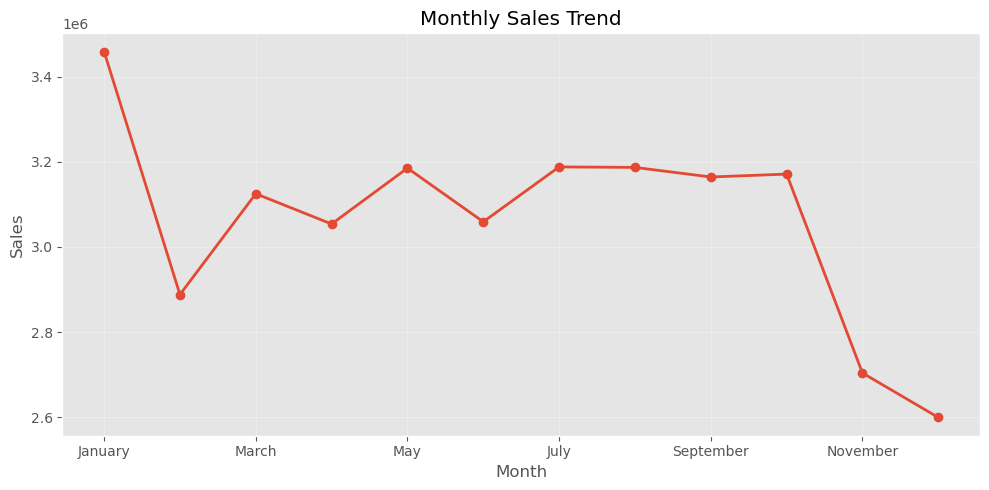

In [8]:
plt.figure(figsize=(10,5))

sales_month.plot(

    marker="o",

    linewidth=2

)

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.xlabel("Month")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [9]:
market_sales = (

    df.groupby("Market")["Sales"]

    .sum()

    .sort_values(ascending=False)

)

market_sales

Market
Europe          1.087240e+07
LATAM           1.027761e+07
Pacific Asia    8.273744e+06
USCA            5.066529e+06
Africa          2.294453e+06
Name: Sales, dtype: float64

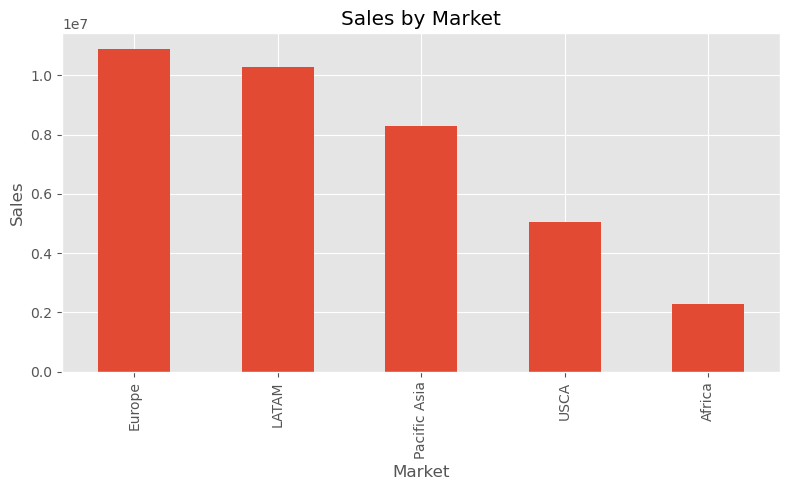

In [10]:
plt.figure(figsize=(8,5))

market_sales.plot(kind="bar")

plt.title("Sales by Market")

plt.ylabel("Sales")

plt.xlabel("Market")

plt.tight_layout()

plt.show()

# 📌 Key Business Insights

- Europe generated the highest overall revenue.

- More than 65,000 customer orders were processed.

- The company served over 20,000 unique customers.

- Monthly sales remained relatively stable throughout the year with seasonal fluctuations.

- Overall business profitability remained positive.

# 💡 Business Recommendations

- Increase investment in high-performing markets.

- Improve customer retention strategies.

- Optimize inventory based on monthly demand patterns.

- Focus on improving overall profit margins.

- Expand successful product categories into underperforming regions.